# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

In [15]:
data_appl = pd.read_csv('AAPL.csv')

In [16]:
data_appl.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [17]:
# Get some info about the data
data_appl.info()

<class 'pandas.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  str    
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), str(1)
memory usage: 579.3 KB


In [ ]:
df = data_appl
feature_columns = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
num_features = len(feature_columns)

X_data = []
y_data = []
window_size = 30

for i in range(1, len(df) - window_size - 1):
    data_feature = []
    data_label = []

    for j in range(window_size):
        data_feature.append(df[feature_columns].iloc[i + j].values)

    data_label.append(df['Open'].iloc[i + window_size])

    X_data.append(np.array(data_feature))
    y_data.append(np.array(data_label))


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("Shape of training set: ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set: ", X_test.shape)
print("Number of features: ", X_train.shape[2])

Shape of training set:  (6756, 30, 6)
Shape of validation set:  (1690, 30, 6)
Shape of test set:  (2112, 30, 6)
Number of features:  6


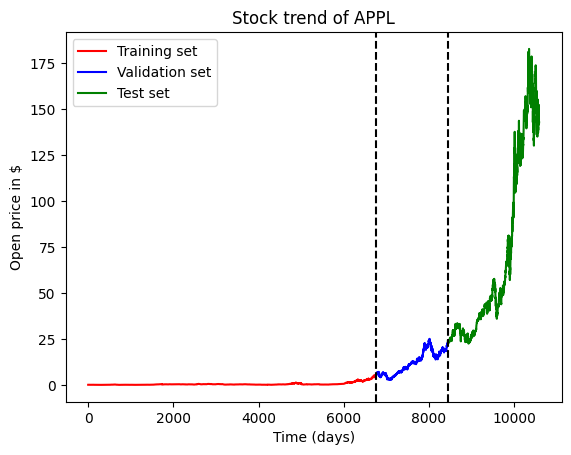

In [ ]:
df_plot = df['Open']
df_plot = df_plot.reset_index(drop=False)

size_train = X_train.shape[0]
size_val = X_val.shape[0]
size_test = X_test.shape[0]

ax = df_plot.iloc[:size_train,1:2].plot(y=0, color='red', label='Training set')
df_plot.iloc[size_train:size_train+size_val,1:2].plot(y=0, color='blue', label='Validation set', ax=ax)
df_plot.iloc[size_train+size_val:df_plot.shape[0],1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of APPL")
plt.xlabel('Time (days)')
plt.ylabel('Open price in $')
plt.axvline(x=size_train, color='black', linestyle='--')
plt.axvline(x=size_train+size_val, color='black', linestyle='--')
plt.show()

In [ ]:
def normalize_multifeature(X, y):
    """MinMax normalize X per feature per sample. Normalize y using Open price stats."""
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    for i in range(len(X)):
        for f in range(X.shape[2]):  # for each feature column
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            if denom == 0:
                X_norm[i, :, f] = 0
            else:
                X_norm[i, :, f] = (X[i, :, f] - min_val) / denom
        # Normalize label (Open price) using Open column (index 1) stats
        open_min = np.min(X[i, :, 1])
        open_max = np.max(X[i, :, 1])
        open_denom = open_max - open_min
        if open_denom == 0:
            y_norm[i] = 0
        else:
            y_norm[i] = (y[i] - open_min) / open_denom
    return X_norm, y_norm

X_train_norm, y_train_norm = normalize_multifeature(X_train, y_train)

X_val_norm, y_val_norm = normalize_multifeature(X_val, y_val)

In [ ]:
model = tf.keras.Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history = model.fit(X_train_norm, y_train_norm, validation_data=(X_val_norm, y_val_norm), epochs=5, batch_size=512)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.7455 - mse: 0.7455 - val_loss: 0.1931 - val_mse: 0.1931
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1770 - mse: 0.1770 - val_loss: 0.1479 - val_mse: 0.1479
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1503 - mse: 0.1503 - val_loss: 0.1262 - val_mse: 0.1262
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0953 - mse: 0.0953 - val_loss: 0.0731 - val_mse: 0.0731
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0676 - mse: 0.0676 - val_loss: 0.0596 - val_mse: 0.0596


In [ ]:
X_test_norm, y_test_norm = normalize_multifeature(X_test, y_test)

In [ ]:
y_pred_norm = model.predict(X_test_norm)
print("MSE on the test set: ", mean_squared_error(y_pred_norm, y_test_norm))

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MSE on the test set:  0.06066341114596852


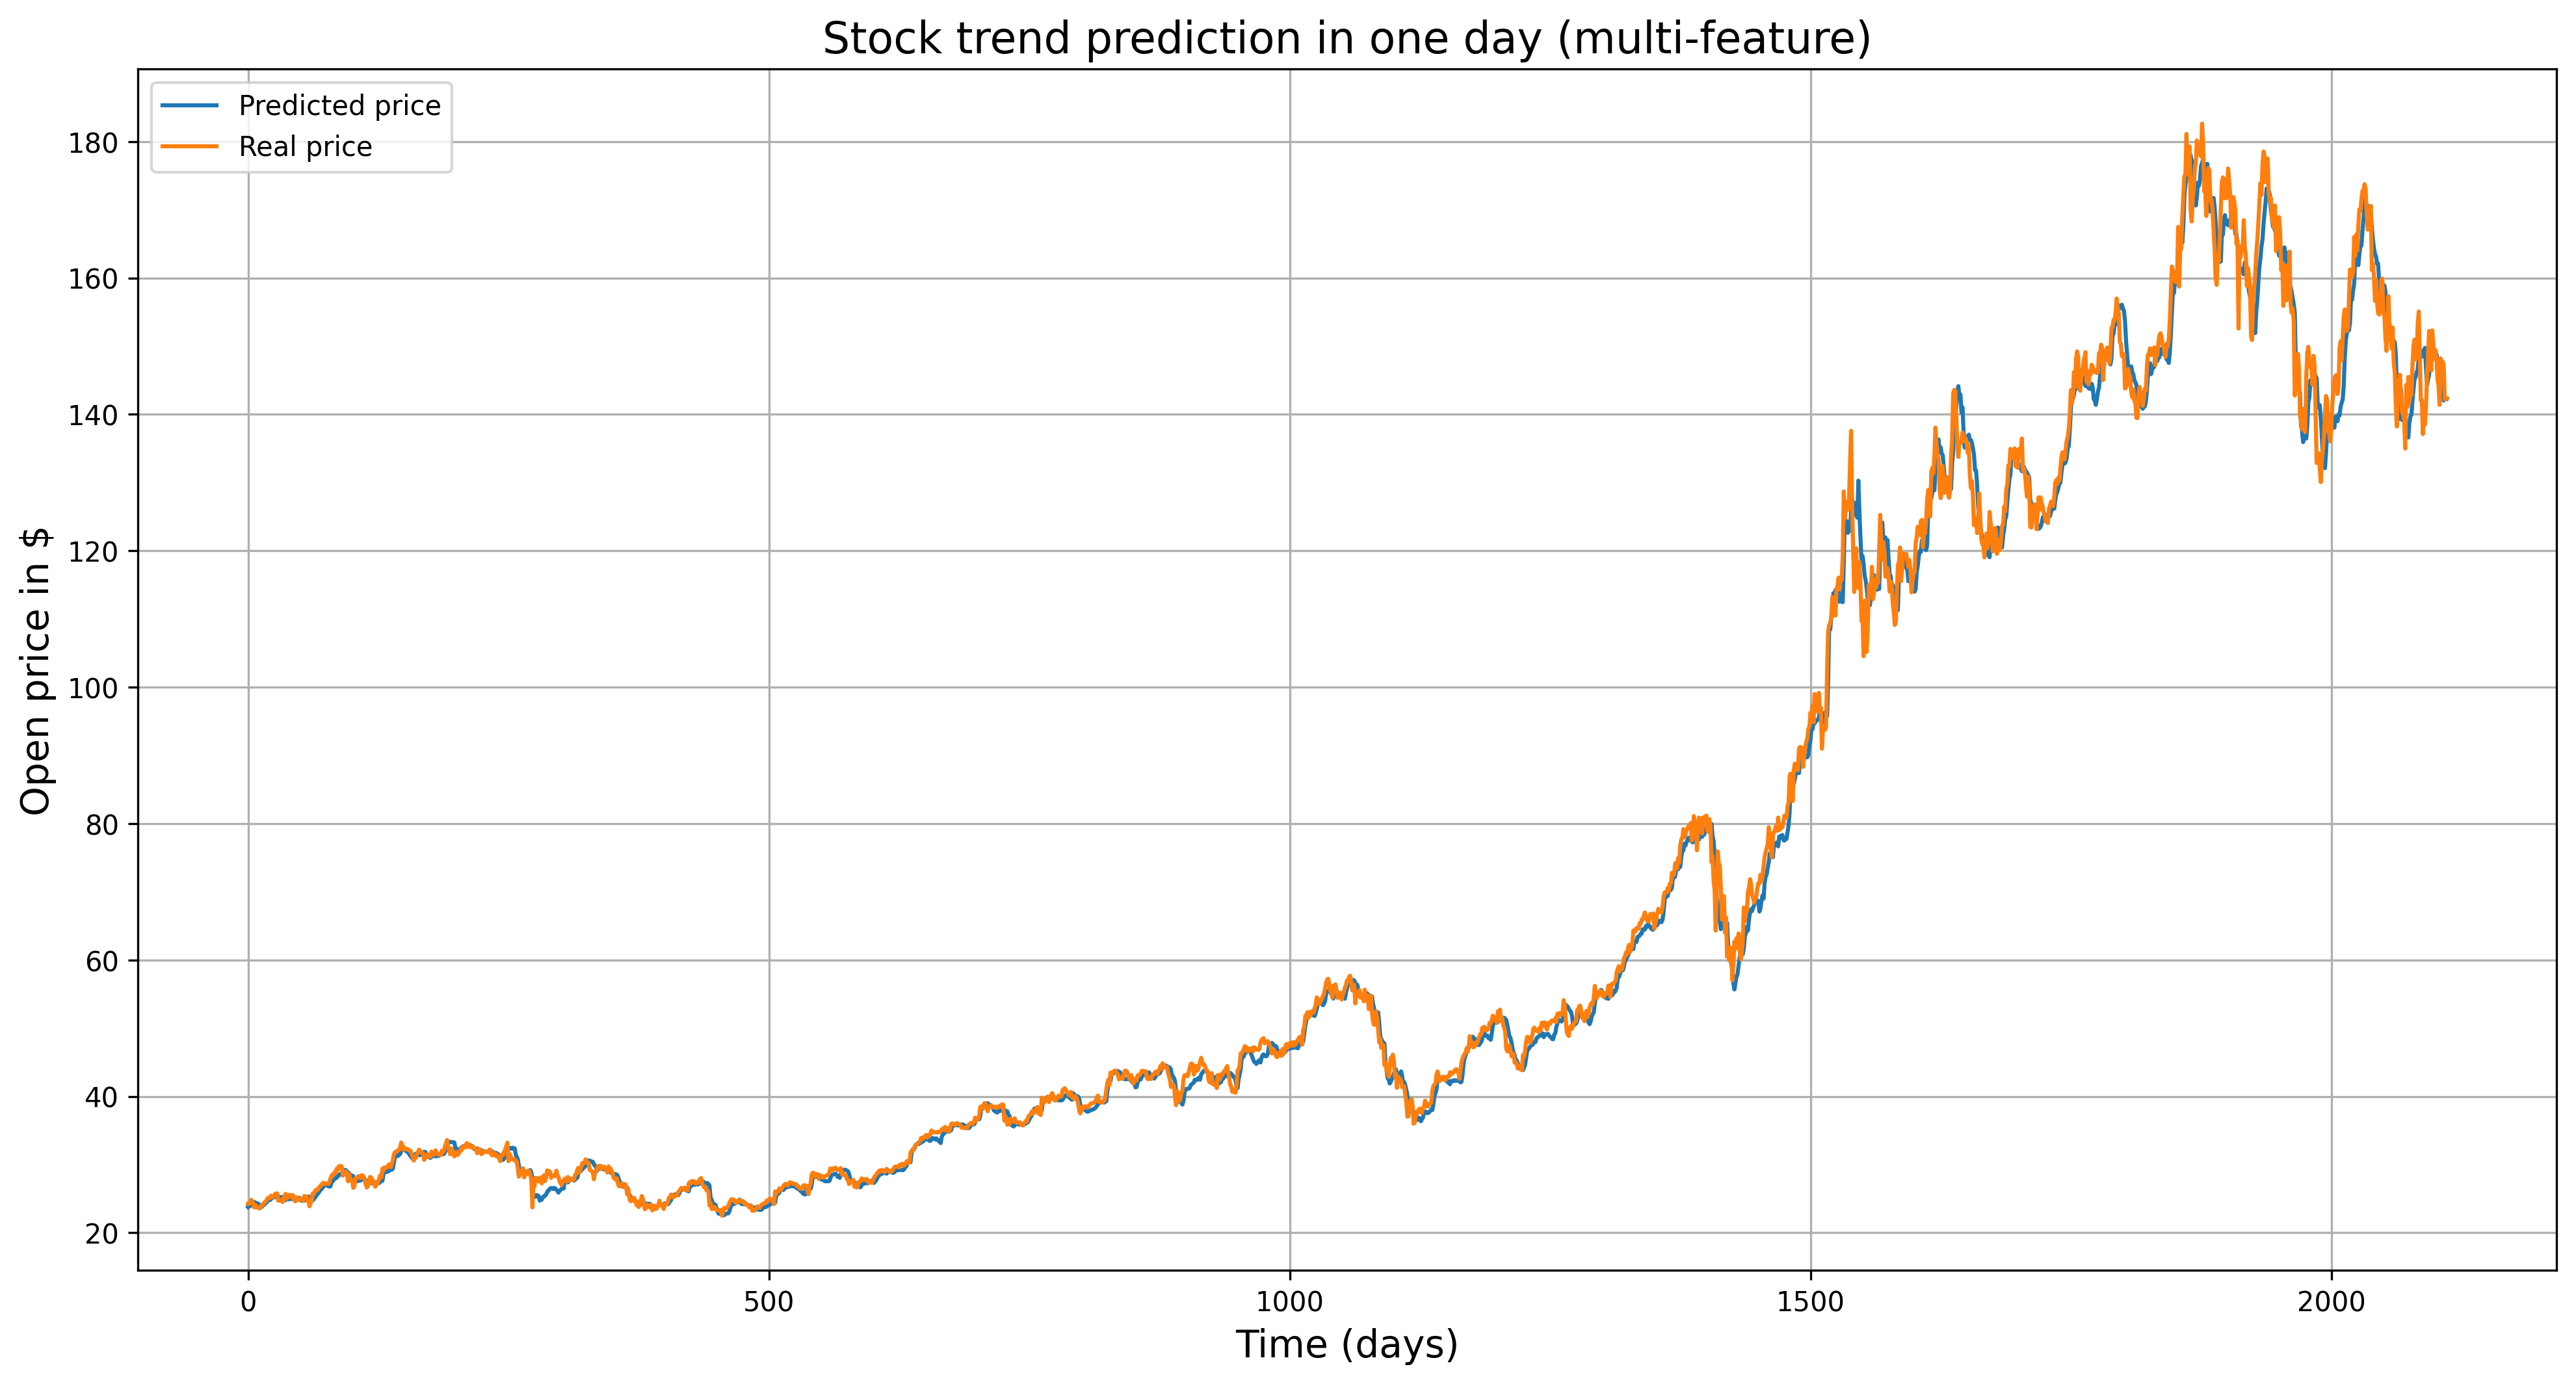

In [ ]:
y_pred_denorm = y_pred_norm.copy()
for i in range(0, len(y_pred_denorm)):
    open_min = np.min(X_test[i, :, 1])
    open_max = np.max(X_test[i, :, 1])
    y_pred_denorm[i] = y_pred_norm[i] * (open_max - open_min) + open_min

# Visualize predicted stock price versus real stock price
plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm, label='Predicted price')
plt.plot(y_test, label='Real price')
plt.title('Stock trend prediction in one day (multi-feature)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open price in $', fontsize=14)
plt.grid() # Add grid
plt.legend() # Add legend
plt.show()